EMAIL SPAM DETECTION
Oasis Infobyte Internship

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer  # sentences --> numbers conversion
from sklearn.naive_bayes import MultinomialNB    # Naive Bayes model's who can predict category of text data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ---------- Load Dataset ----------

df = pd.read_csv("spam.csv", encoding='latin-1')

# Show first 5 rows
print("First 5 Rows:\n")
print(df.head())

# Dataset shape
print("\nDataset Shape:", df.shape)

First 5 Rows:

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Dataset Shape: (5572, 5)


In [3]:
# ---------- Data Cleaning ----------

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check column names
print(df.columns)

# Keep only useful columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['Category', 'Message']

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Check spam and ham counts
print("\nMessage Categories:\n")
print(df['Category'].value_counts())

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Missing Values:

Category    0
Message     0
dtype: int64

Message Categories:

ham     4825
spam     747
Name: Category, dtype: int64


In [4]:
# ---------- Convert Labels ----------
# ham = 0
# spam = 1

df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})


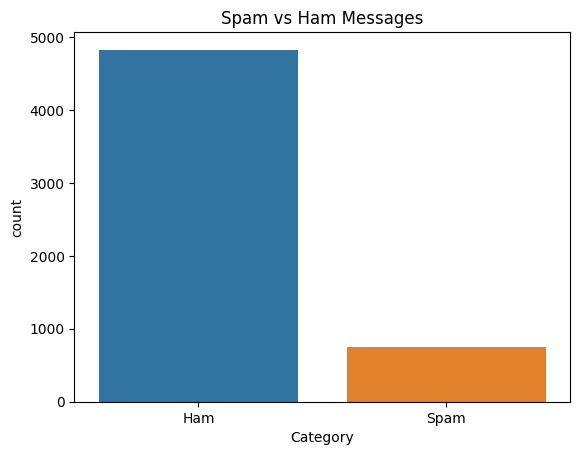

In [ ]:
# ---------- Data Visualization ----------

sns.countplot(x=df['Category'])
plt.xticks([0,1], ['Ham', 'Spam'])
plt.title("Spam vs Ham Messages")
plt.show()

In [8]:
# ---------- Split Data ----------

X = df['Message']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
# ---------- Convert Text to Numbers ----------
# TF-IDF converts text into numeric format

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)


In [11]:

model = MultinomialNB()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)


In [12]:
# ---------- Model Evaluation ----------


accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:",
      round(accuracy * 100, 2), "%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Model Accuracy: 96.23 %

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



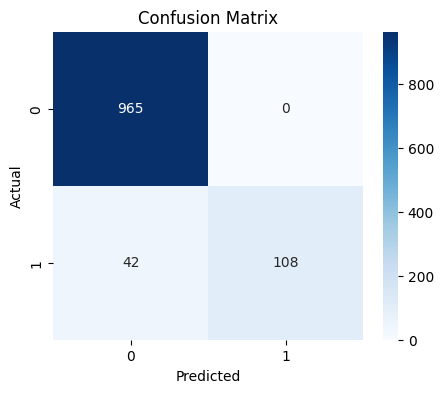

In [13]:
# ---------- Confusion Matrix ----------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [14]:
# ---------- Manual Testing ----------

sample_messages = [
    "Congratulations! You won a free iPhone",
    "Hey bro, are you coming to college today?"
]

# Convert text into numeric form
sample_data = vectorizer.transform(sample_messages)

# Predict
predictions = model.predict(sample_data)

print("\nManual Predictions:\n")

for message, prediction in zip(sample_messages, predictions):

    if prediction == 1:
        result = "Spam"
    else:
        result = "Ham"

    print(f"Message: {message}")
    print("Prediction:", result)
    print()


Manual Predictions:

Message: Congratulations! You won a free iPhone
Prediction: Spam

Message: Hey bro, are you coming to college today?
Prediction: Ham



In [15]:
# ---------- Final Conclusion ----------

print("Conclusion:")
print("The model successfully classified spam and non-spam emails.")
print("Machine Learning can help detect unwanted messages automatically.")

Conclusion:
The model successfully classified spam and non-spam emails.
Machine Learning can help detect unwanted messages automatically.
